In [1]:
# Khai báo Thư viện & Cấu hình
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
import time
import numpy as np

# Cấu hình biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Functions
def load_and_clean_data(filepath="ad.data"):
    print("\n[1/6] Loading and cleaning data...")
    try:
        df = pd.read_csv(filepath, header=None, low_memory=False)
    except FileNotFoundError:
        print(f"ERROR: File '{filepath}' not found."); return None
    df.rename(columns={1558: "label"}, inplace=True)
    df = df.replace(to_replace='[?]', value=np.nan, regex=True)
    df.dropna(inplace=True)
    feature_cols = df.columns[:-1]
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric)
    return df

def prepare_data(df):
    df["label"] = df["label"].apply(lambda x: 1 if str(x).strip() == "ad." else 0)
    X = df.drop("label", axis=1).values
    y = df["label"].values
    return train_test_split(X, y)

def train_model(X_train, y_train):
    clf = RandomForestClassifier()
    clf.fit(X_train, y_train)
    return clf

def visualize_results(clf, y_test, y_pred, feature_names=None):
    """Trực quan hóa kết quả — 3 hình riêng biệt."""
    sns.set_theme(style="whitegrid", palette="muted")

    # --- Hình 1: Confusion Matrix ---
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                annot_kws={"size": 15, "weight": "bold"}, cbar=False)
    ax1.set_title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, pad=15)
    ax1.set_xticklabels(['Sạch (Dự đoán)', 'Ads (Dự đoán)'], fontsize=12)
    ax1.set_yticklabels(['Sạch (Thực tế)', 'Ads (Thực tế)'], fontsize=12)
    ax1.set_xlabel('Predicted Label', fontsize=12)
    ax1.set_ylabel('Actual Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('model1_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Hình 2: Classification Report ---
    from sklearn.metrics import classification_report
    import pandas as pd

    report = classification_report(y_test, y_pred,
                                   target_names=["Sạch", "Quảng cáo"],
                                   output_dict=True)
    df_report = pd.DataFrame(report).T.drop("support", axis=1).iloc[:4]

    fig2, ax2 = plt.subplots(figsize=(8, 4))
    sns.heatmap(df_report, annot=True, fmt=".2f", cmap="Blues",
                linewidths=0.5, vmin=0, vmax=1, ax=ax2, cbar=False,
                annot_kws={"size": 13, "weight": "bold"})
    ax2.set_title('Báo cáo phân loại (Classification Report)', fontsize=14, pad=15)
    ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=12)
    ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=12, rotation=0)
    plt.tight_layout()
    plt.savefig('model1_classification_report.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Hình 3: Feature Importance ---
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    importances = clf.feature_importances_
    indices = np.argsort(importances)[-10:]
    names = [feature_names[i] if feature_names is not None else f"Feature {i}" for i in indices]
    ax3.barh(range(len(indices)), importances[indices], color='teal', align='center', edgecolor='black')
    ax3.set_yticks(range(len(indices)))
    ax3.set_yticklabels(names, fontsize=11)
    ax3.set_title('Top 10 Đặc trưng quan trọng nhất (Feature Importance)', fontsize=14, pad=15)
    ax3.set_xlabel('Gini Importance / Information Gain')
    ax3.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('model1_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

In [3]:
# Nạp & Làm sạch Dữ liệu
df = load_and_clean_data("ad.data")
if df is not None:
    print(f"Dữ liệu sau khi làm sạch: {df.shape}")
    print(df.head())


[1/6] Loading and cleaning data...
Dữ liệu sau khi làm sạch: (2359, 1559)
     0    1       2  3  4  5  6  7  8  9  ...  1549  1550  1551  1552  1553  \
0  125  125  1.0000  1  0  0  0  0  0  0  ...     0     0     0     0     0   
1   57  468  8.2105  1  0  0  0  0  0  0  ...     0     0     0     0     0   
2   33  230  6.9696  1  0  0  0  0  0  0  ...     0     0     0     0     0   
3   60  468  7.8000  1  0  0  0  0  0  0  ...     0     0     0     0     0   
4   60  468  7.8000  1  0  0  0  0  0  0  ...     0     0     0     0     0   

   1554  1555  1556  1557  label  
0     0     0     0     0    ad.  
1     0     0     0     0    ad.  
2     0     0     0     0    ad.  
3     0     0     0     0    ad.  
4     0     0     0     0    ad.  

[5 rows x 1559 columns]


In [4]:
# Phân tách Tập dữ liệu (Train / Test)
X_train, X_test, y_train, y_test = prepare_data(df)
print(f" Kích thước Train: {X_train.shape} | Kích thước Test: {X_test.shape}")

 Kích thước Train: (1769, 1558) | Kích thước Test: (590, 1558)


In [5]:
# Bước 3 — Huấn luyện Mô hình (Random Forest)
print("Đang huấn luyện mô hình...")
clf = train_model(X_train, y_train)
print("Mô hình đã được huấn luyện thành công.")

Đang huấn luyện mô hình...
Mô hình đã được huấn luyện thành công.


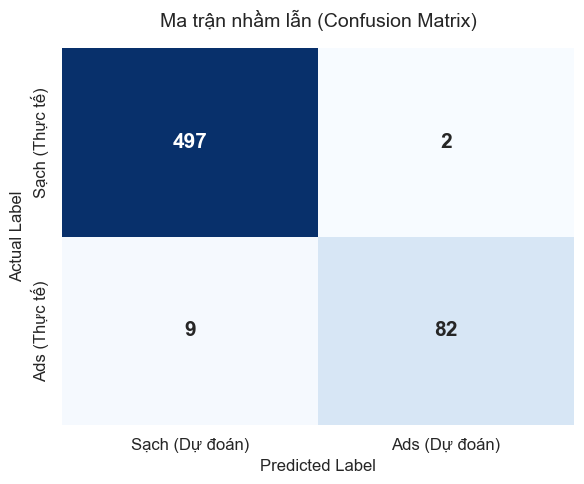

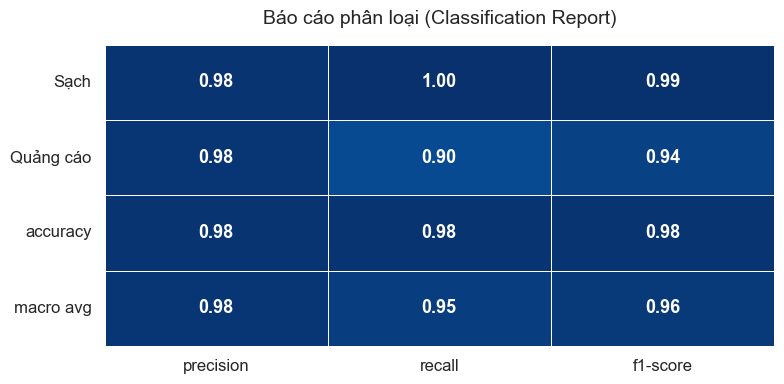

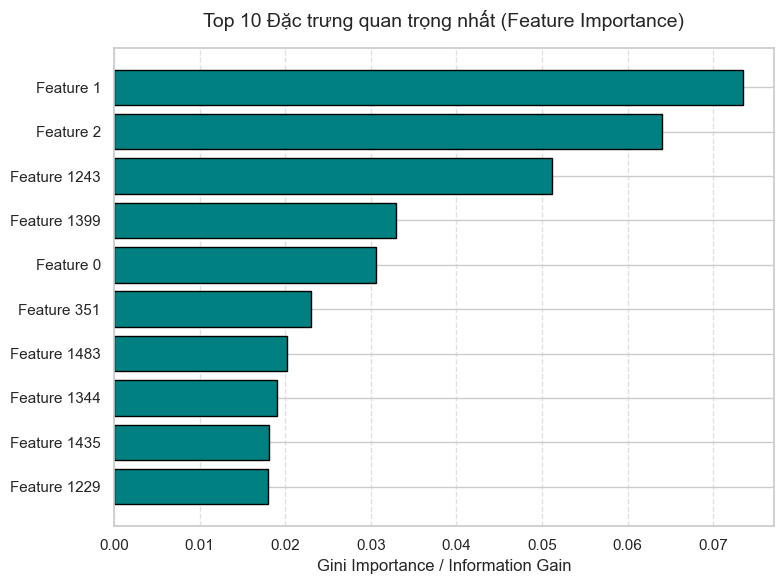

Mô hình đã được lưu tại: original_dataset.joblib


In [6]:
# Trực quan hóa Kết quả & Lưu trữ Mô hình
y_pred = clf.predict(X_test)
visualize_results(clf, y_test, y_pred)

# Lưu model
joblib.dump(clf, "original_dataset.joblib")
print("Mô hình đã được lưu tại: original_dataset.joblib")